In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Test on weather variables

## ELEC

### Plot initial puissance vs température

In [2]:
CONSO_PATH = "base_data/FR_elec/conso_reg_daily.csv"
TEMP_PATH = "base_data/temp_era/temp_FR_daily_era.csv"

conso = pd.read_csv(CONSO_PATH, index_col=0, parse_dates = True)
temp = pd.read_csv(TEMP_PATH, index_col=0, parse_dates = True)

In [3]:
saisons = {1: "winter", 2: "winter", 3: "spring", 4: "spring", 5: "spring",
           6: "summer", 7: "summer", 8: "summer", 9: "fall", 10: "fall",
           11: "fall", 12: "winter"}
couleurs = {"winter": "royalblue", "spring": "mediumseagreen",
            "summer": "tomato", "fall": "darkorange"}

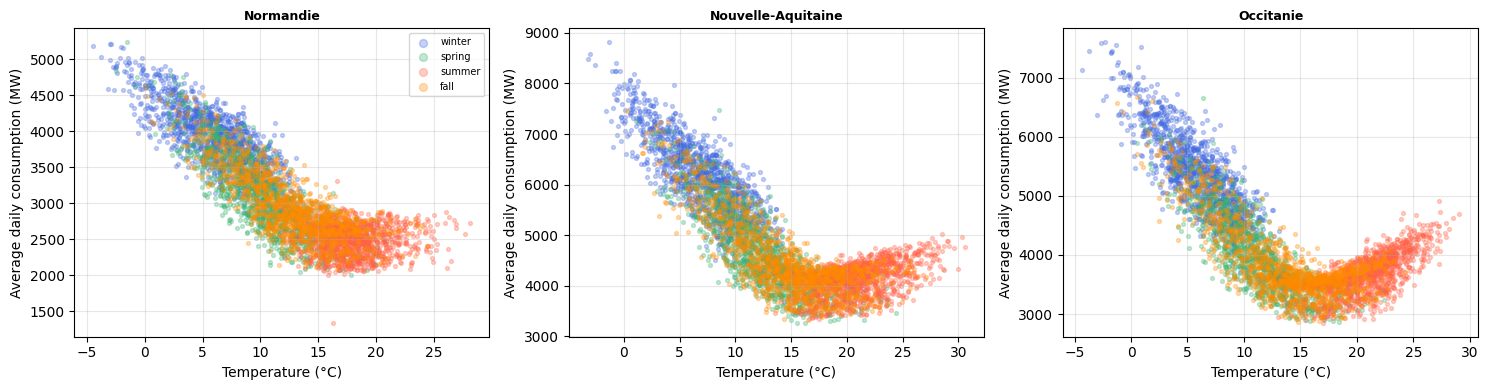

In [4]:
regions = conso.columns.tolist()
regions = ["Normandie", "Nouvelle-Aquitaine", "Occitanie"]
ncols = 3
nrows = int(np.ceil(len(regions) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 4))
axes = axes.flatten()

for idx, region in enumerate(regions):
    ax = axes[idx]
    
    common = conso[region].dropna().index.intersection(temp[region].dropna().index)
    x = temp[region].loc[common]
    y = conso[region].loc[common]
    months = common.month

    for saison, color in couleurs.items():
        mask = months.map(saisons) == saison
        ax.scatter(x[mask], y[mask], alpha=0.3, s=8, color=color, label=saison)

    
    #ax.scatter(x, y, alpha=0.3, s=8, color="steelblue")
    ax.set_title(region, fontsize=9, fontweight="bold")
    ax.set_xlabel("Temperature (°C)")
    ax.set_ylabel("Average daily consumption (MW)")
    ax.grid(True, alpha=0.3)
    if idx == 0:
        ax.legend(fontsize=7, markerscale=2)    

for idx in range(len(regions), len(axes)):
    axes[idx].set_visible(False)

#plt.suptitle("Consumption vs daily average temperature per region", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


Jour de la semaine

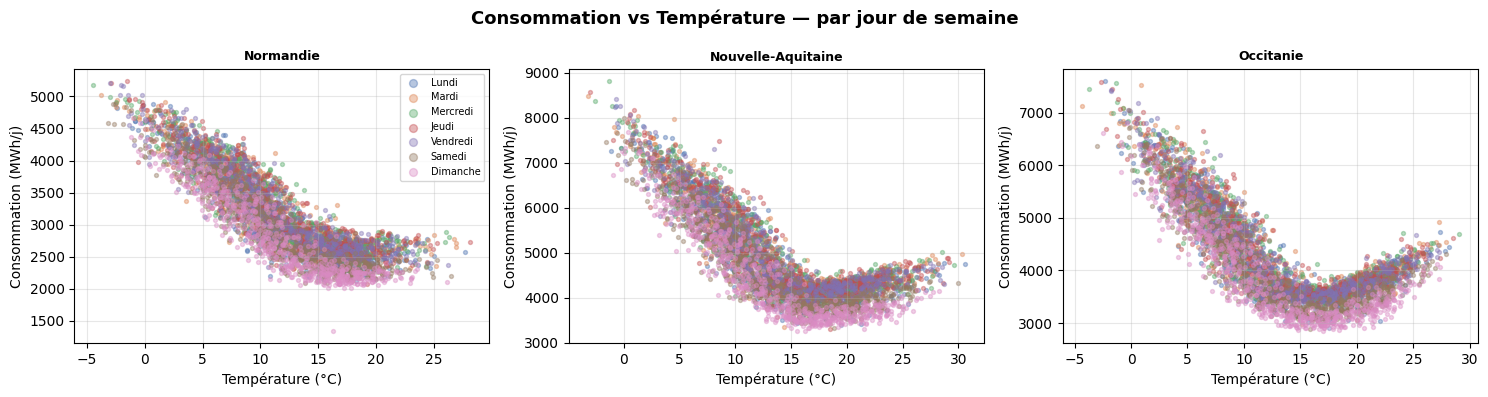

In [5]:
jours = {0: "Lundi", 1: "Mardi", 2: "Mercredi", 3: "Jeudi",
         4: "Vendredi", 5: "Samedi", 6: "Dimanche"}
couleurs_dow = {
    "Lundi": "#4C72B0", "Mardi": "#DD8452", "Mercredi": "#55A868",
    "Jeudi": "#C44E52", "Vendredi": "#8172B3", "Samedi": "#937860", "Dimanche": "#DA8BC3"
}

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 4))
axes = axes.flatten()

for idx, region in enumerate(regions):
    ax = axes[idx]
    common = conso[region].dropna().index.intersection(temp[region].dropna().index)
    x = temp[region].loc[common]
    y = conso[region].loc[common]

    for dow, jour in jours.items():
        mask = common.dayofweek == dow
        ax.scatter(x[mask], y[mask], alpha=0.4, s=8,
                   color=couleurs_dow[jour], label=jour)

    ax.set_title(region, fontsize=9, fontweight="bold")
    ax.set_xlabel("Température (°C)")
    ax.set_ylabel("Consommation (MWh/j)")
    ax.grid(True, alpha=0.3)
    if idx == 0:
        ax.legend(fontsize=7, markerscale=2)

for idx in range(len(regions), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("Consommation vs Température — par jour de semaine", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


Séparation uniquement jour de la semaine et week-end

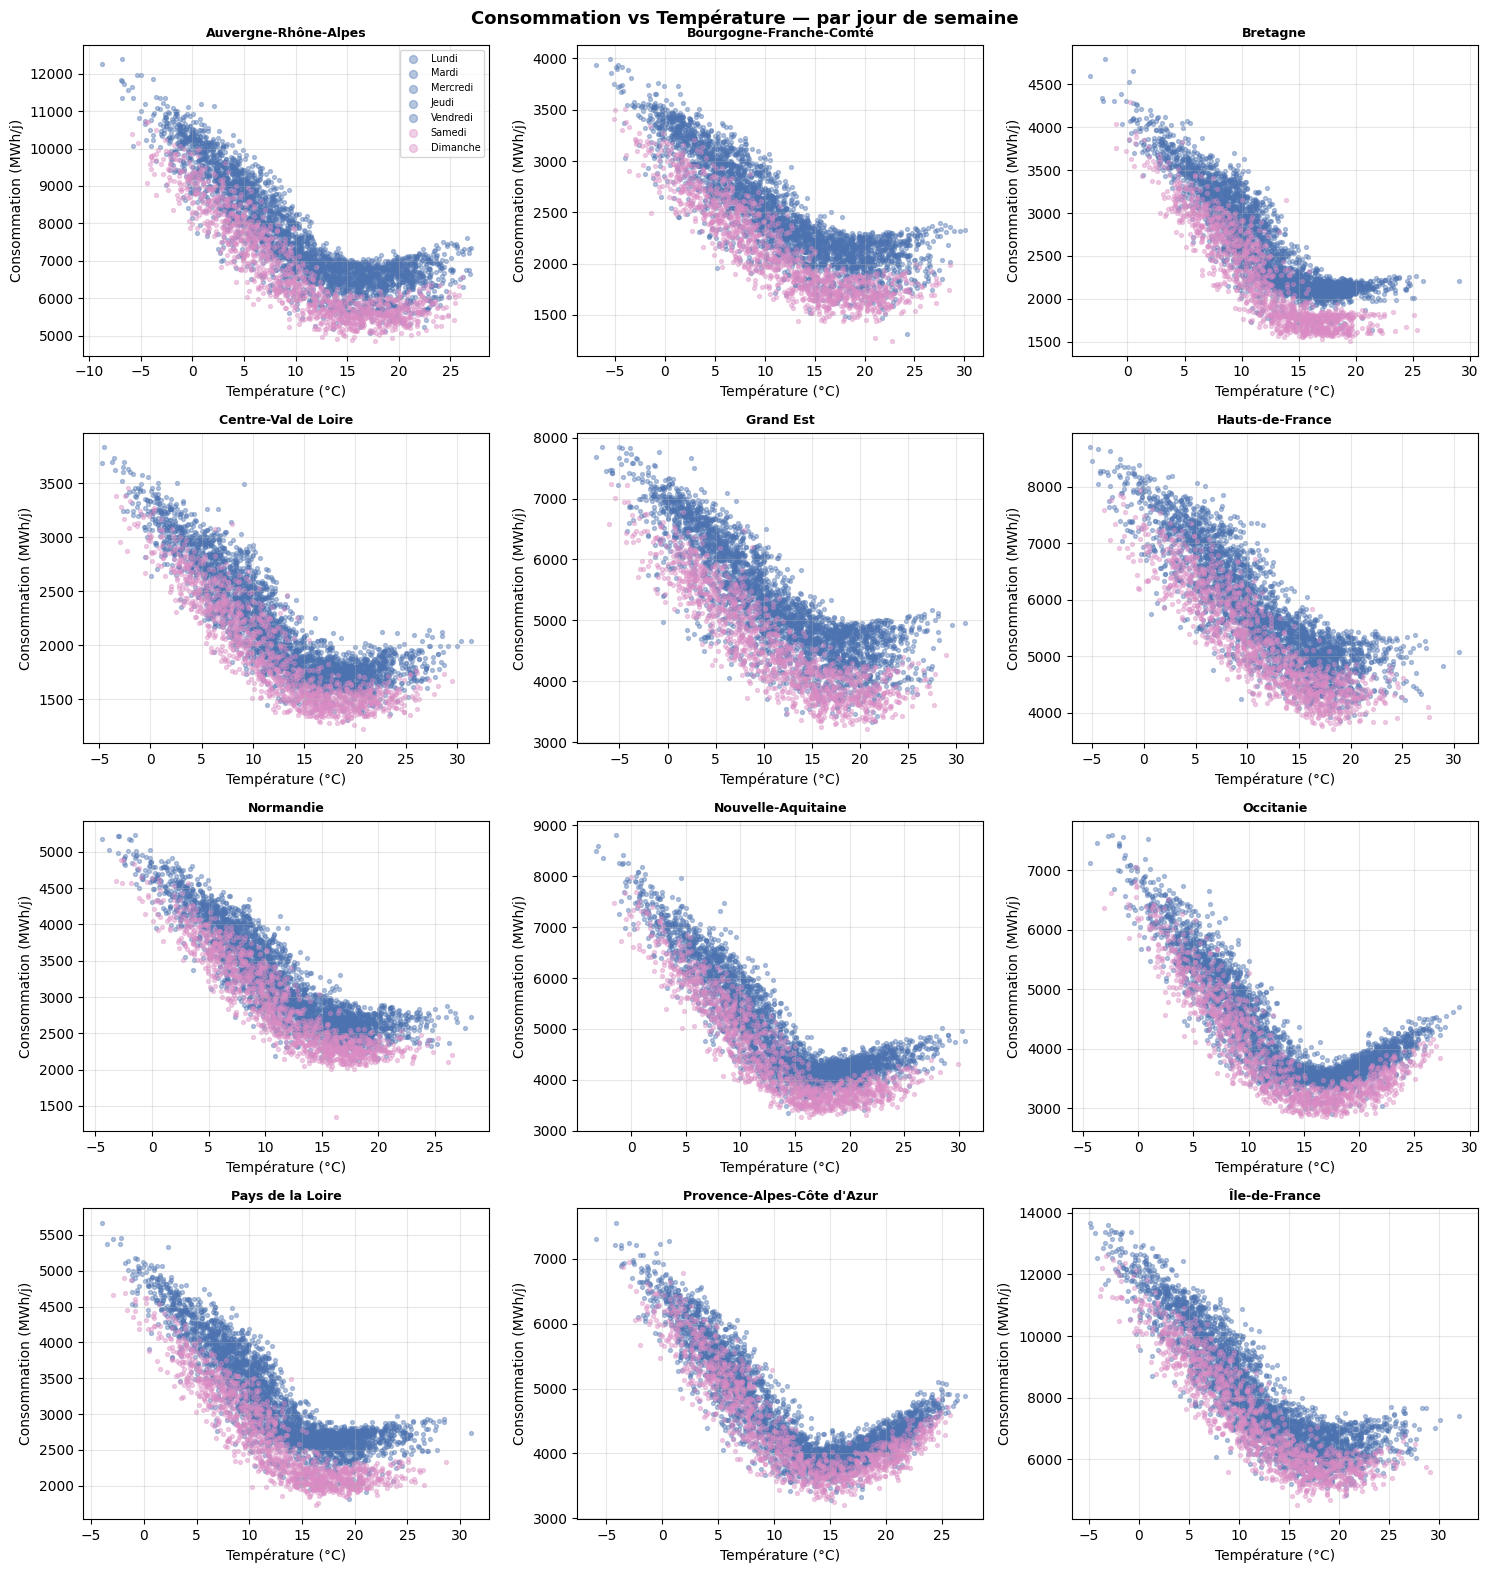

In [7]:
jours = {0: "Lundi", 1: "Mardi", 2: "Mercredi", 3: "Jeudi",
         4: "Vendredi", 5: "Samedi", 6: "Dimanche"}
couleurs_dow = {
    "Lundi": "#4C72B0", "Mardi": "#4C72B0", "Mercredi": "#4C72B0",
    "Jeudi": "#4C72B0", "Vendredi": "#4C72B0", "Samedi": "#DA8BC3", "Dimanche": "#DA8BC3"
}

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 4))
axes = axes.flatten()

for idx, region in enumerate(regions):
    ax = axes[idx]
    common = conso[region].dropna().index.intersection(temp[region].dropna().index)
    x = temp[region].loc[common]
    y = conso[region].loc[common]

    for dow, jour in jours.items():
        mask = common.dayofweek == dow
        ax.scatter(x[mask], y[mask], alpha=0.4, s=8,
                   color=couleurs_dow[jour], label=jour)

    ax.set_title(region, fontsize=9, fontweight="bold")
    ax.set_xlabel("Température (°C)")
    ax.set_ylabel("Consommation (MWh/j)")
    ax.grid(True, alpha=0.3)
    if idx == 0:
        ax.legend(fontsize=7, markerscale=2)

for idx in range(len(regions), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("Consommation vs Température — par jour de semaine", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

A creuser si il ne pourrait pas y avoir un lien différent entre jour de la semaine et we en termes de pente et de seuils

C:\Users\hadri\AppData\Local\Temp\ipykernel_120152\2365185016.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("Blues", len(annees) + 3)  # +3 pour éviter les teintes trop claires


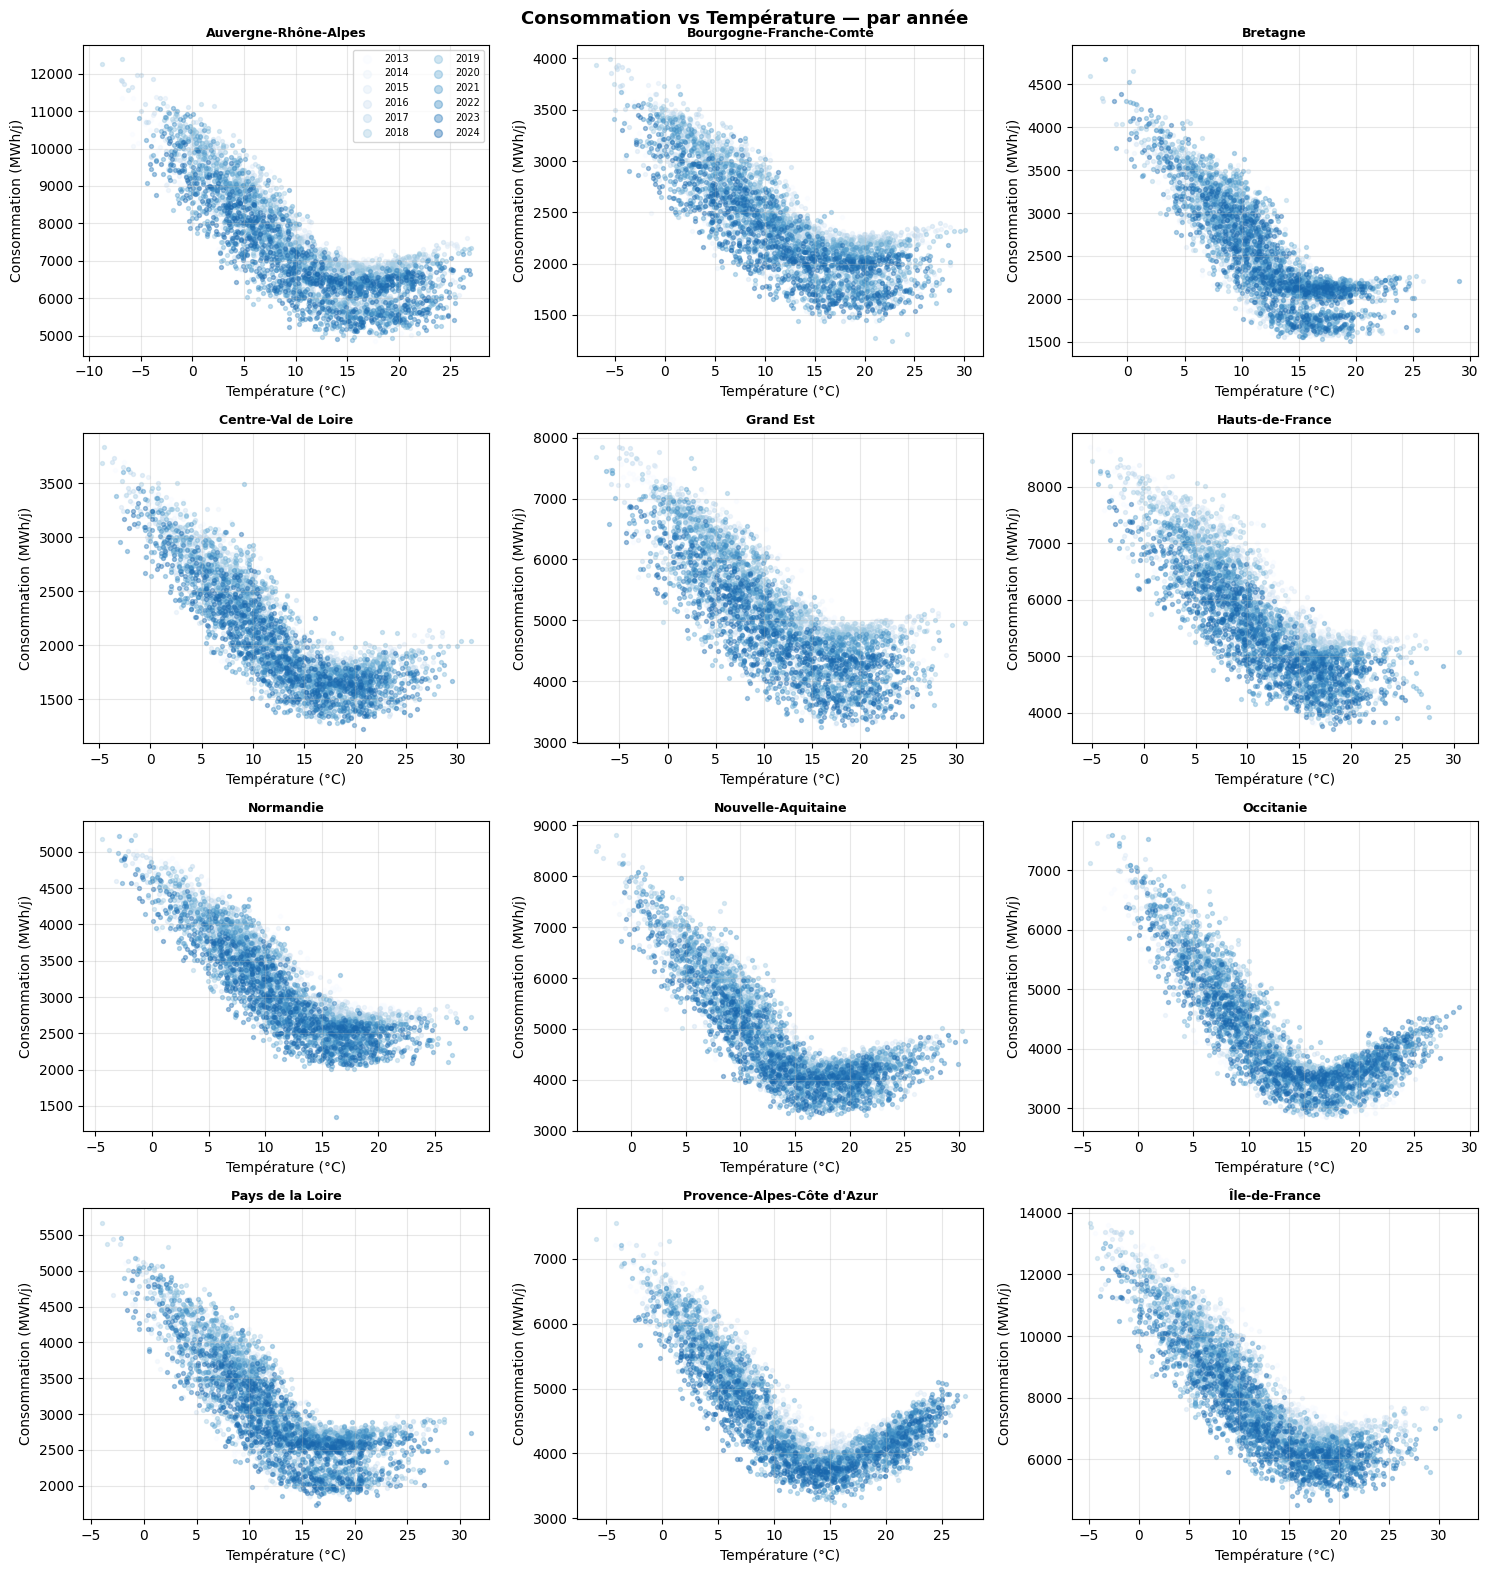

In [8]:
import matplotlib.cm as cm

annees = sorted(conso.index.year.unique())
cmap = cm.get_cmap("Blues", len(annees) + 3)  # +3 pour éviter les teintes trop claires
couleurs_annee = {an: cmap(i + 3) for i, an in enumerate(annees)}

couleurs_annee = {an: cmap(i) for i, an in enumerate(annees)}

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 4))
axes = axes.flatten()

for idx, region in enumerate(regions):
    ax = axes[idx]
    common = conso[region].dropna().index.intersection(temp[region].dropna().index)
    x = temp[region].loc[common]
    y = conso[region].loc[common]

    for an in annees:
        mask = common.year == an
        ax.scatter(x[mask], y[mask], alpha=0.4, s=8,
                   color=couleurs_annee[an], label=str(an))

    ax.set_title(region, fontsize=9, fontweight="bold")
    ax.set_xlabel("Température (°C)")
    ax.set_ylabel("Consommation (MWh/j)")
    ax.grid(True, alpha=0.3)
    if idx == 0:
        ax.legend(fontsize=7, markerscale=2, ncol=2)

for idx in range(len(regions), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("Consommation vs Température — par année", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


C:\Users\hadri\AppData\Local\Temp\ipykernel_120152\3300172953.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_k = cm.get_cmap("tab10", k)
C:\Users\hadri\AppData\Local\Temp\ipykernel_120152\3300172953.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_k = cm.get_cmap("tab10", k)


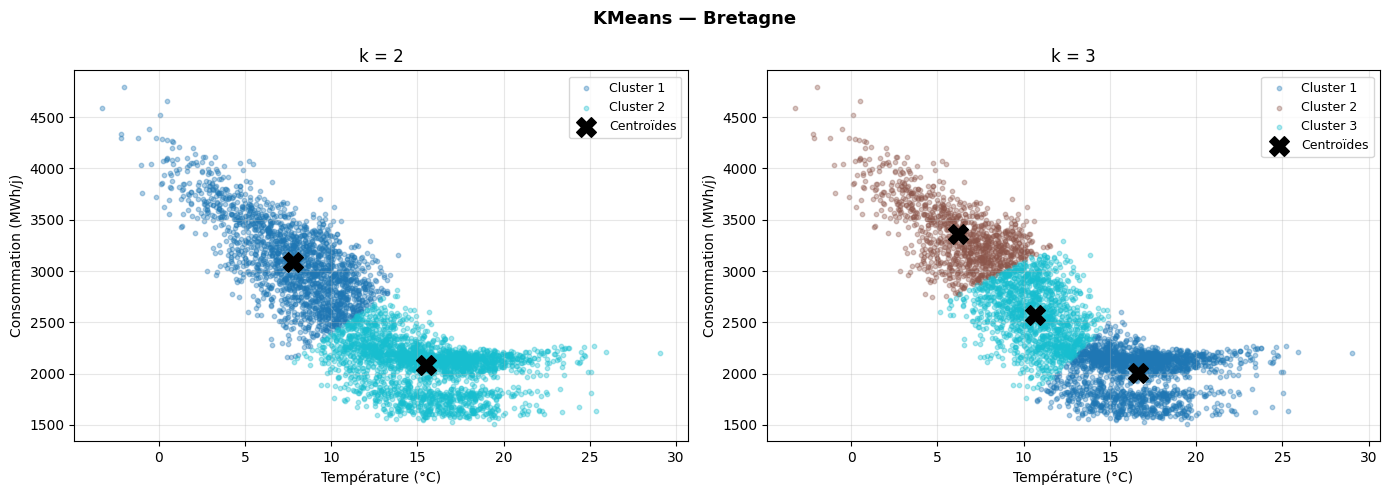

In [9]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

region = "Bretagne"

# --- Données ---
common = conso[region].dropna().index.intersection(temp[region].dropna().index)
X_raw = pd.DataFrame({
    "temperature":  temp[region].loc[common],
    "consommation": conso[region].loc[common],
})

# Normalisation (KMeans est sensible aux échelles)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# --- KMeans k=2 et k=3 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"KMeans — {region}", fontsize=13, fontweight="bold")

for ax, k in zip(axes, [2, 3]):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    centers_scaled = km.cluster_centers_
    centers = scaler.inverse_transform(centers_scaled)

    cmap_k = cm.get_cmap("tab10", k)
    for c in range(k):
        mask = labels == c
        ax.scatter(X_raw["temperature"][mask], X_raw["consommation"][mask],
                   alpha=0.35, s=10, color=cmap_k(c), label=f"Cluster {c+1}")

    # Centroïdes
    ax.scatter(centers[:, 0], centers[:, 1],
               marker="X", s=200, color="black", zorder=5, label="Centroïdes")

    ax.set_title(f"k = {k}")
    ax.set_xlabel("Température (°C)")
    ax.set_ylabel("Consommation (MWh/j)")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


C:\Users\hadri\AppData\Local\Temp\ipykernel_120152\2022172938.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_db       = cm.get_cmap("tab10", max(n_clusters, 1))
C:\Users\hadri\AppData\Local\Temp\ipykernel_120152\2022172938.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_db       = cm.get_cmap("tab10", max(n_clusters, 1))


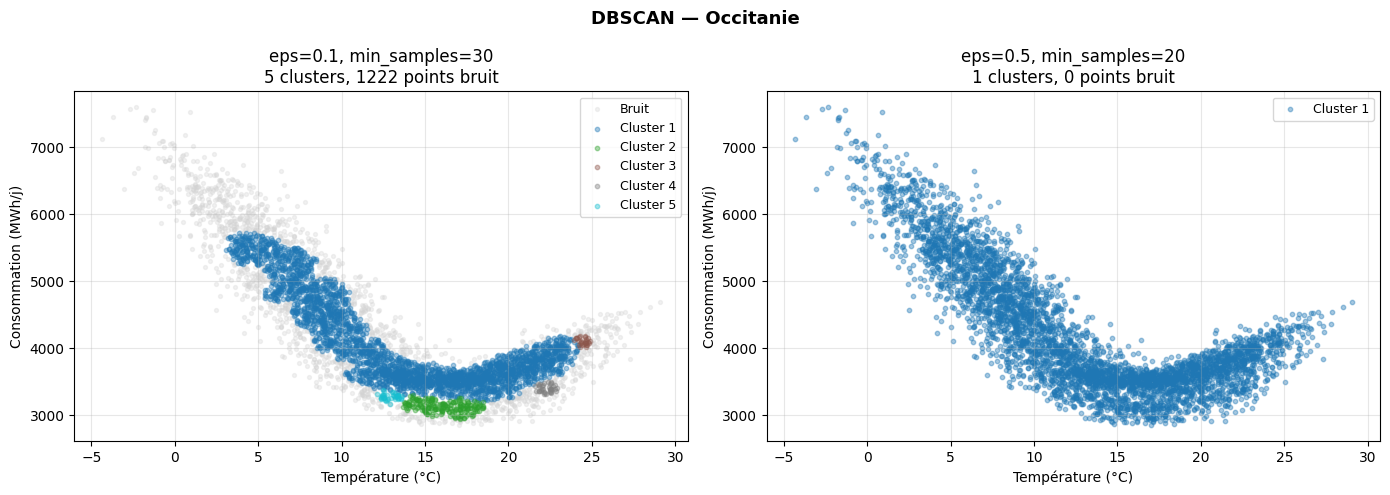

In [10]:
from sklearn.cluster import DBSCAN

region = "Occitanie"

common = conso[region].dropna().index.intersection(temp[region].dropna().index)
X_raw = pd.DataFrame({
    "temperature":  temp[region].loc[common],
    "consommation": conso[region].loc[common],
})

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# --- DBSCAN : tester deux combinaisons de paramètres ---
configs = [
    {"eps": 0.10, "min_samples": 30},
    {"eps": 0.5, "min_samples": 20},
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"DBSCAN — {region}", fontsize=13, fontweight="bold")

for ax, cfg in zip(axes, configs):
    db     = DBSCAN(eps=cfg["eps"], min_samples=cfg["min_samples"])
    labels = db.fit_predict(X_scaled)

    unique_labels = sorted(set(labels))
    n_clusters    = len([l for l in unique_labels if l != -1])
    cmap_db       = cm.get_cmap("tab10", max(n_clusters, 1))

    for l in unique_labels:
        mask = labels == l
        if l == -1:
            ax.scatter(X_raw["temperature"][mask], X_raw["consommation"][mask],
                       alpha=0.3, s=8, color="lightgray", label="Bruit")
        else:
            ax.scatter(X_raw["temperature"][mask], X_raw["consommation"][mask],
                       alpha=0.4, s=10, color=cmap_db(l), label=f"Cluster {l+1}")

    n_noise = (labels == -1).sum()
    ax.set_title(f"eps={cfg['eps']}, min_samples={cfg['min_samples']}\n"
                 f"{n_clusters} clusters, {n_noise} points bruit")
    ax.set_xlabel("Température (°C)")
    ax.set_ylabel("Consommation (MWh/j)")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Potentiellemnt appliquer une régression par morceaux

## Gas

In [11]:
CONSO_PATH = "base_data/conso_gas_reg.csv"
TEMP_PATH = "base_data/temp_reg.csv"

conso = pd.read_csv(CONSO_PATH, index_col=0, parse_dates = True)
temp = pd.read_csv(TEMP_PATH, index_col=0, parse_dates = True)

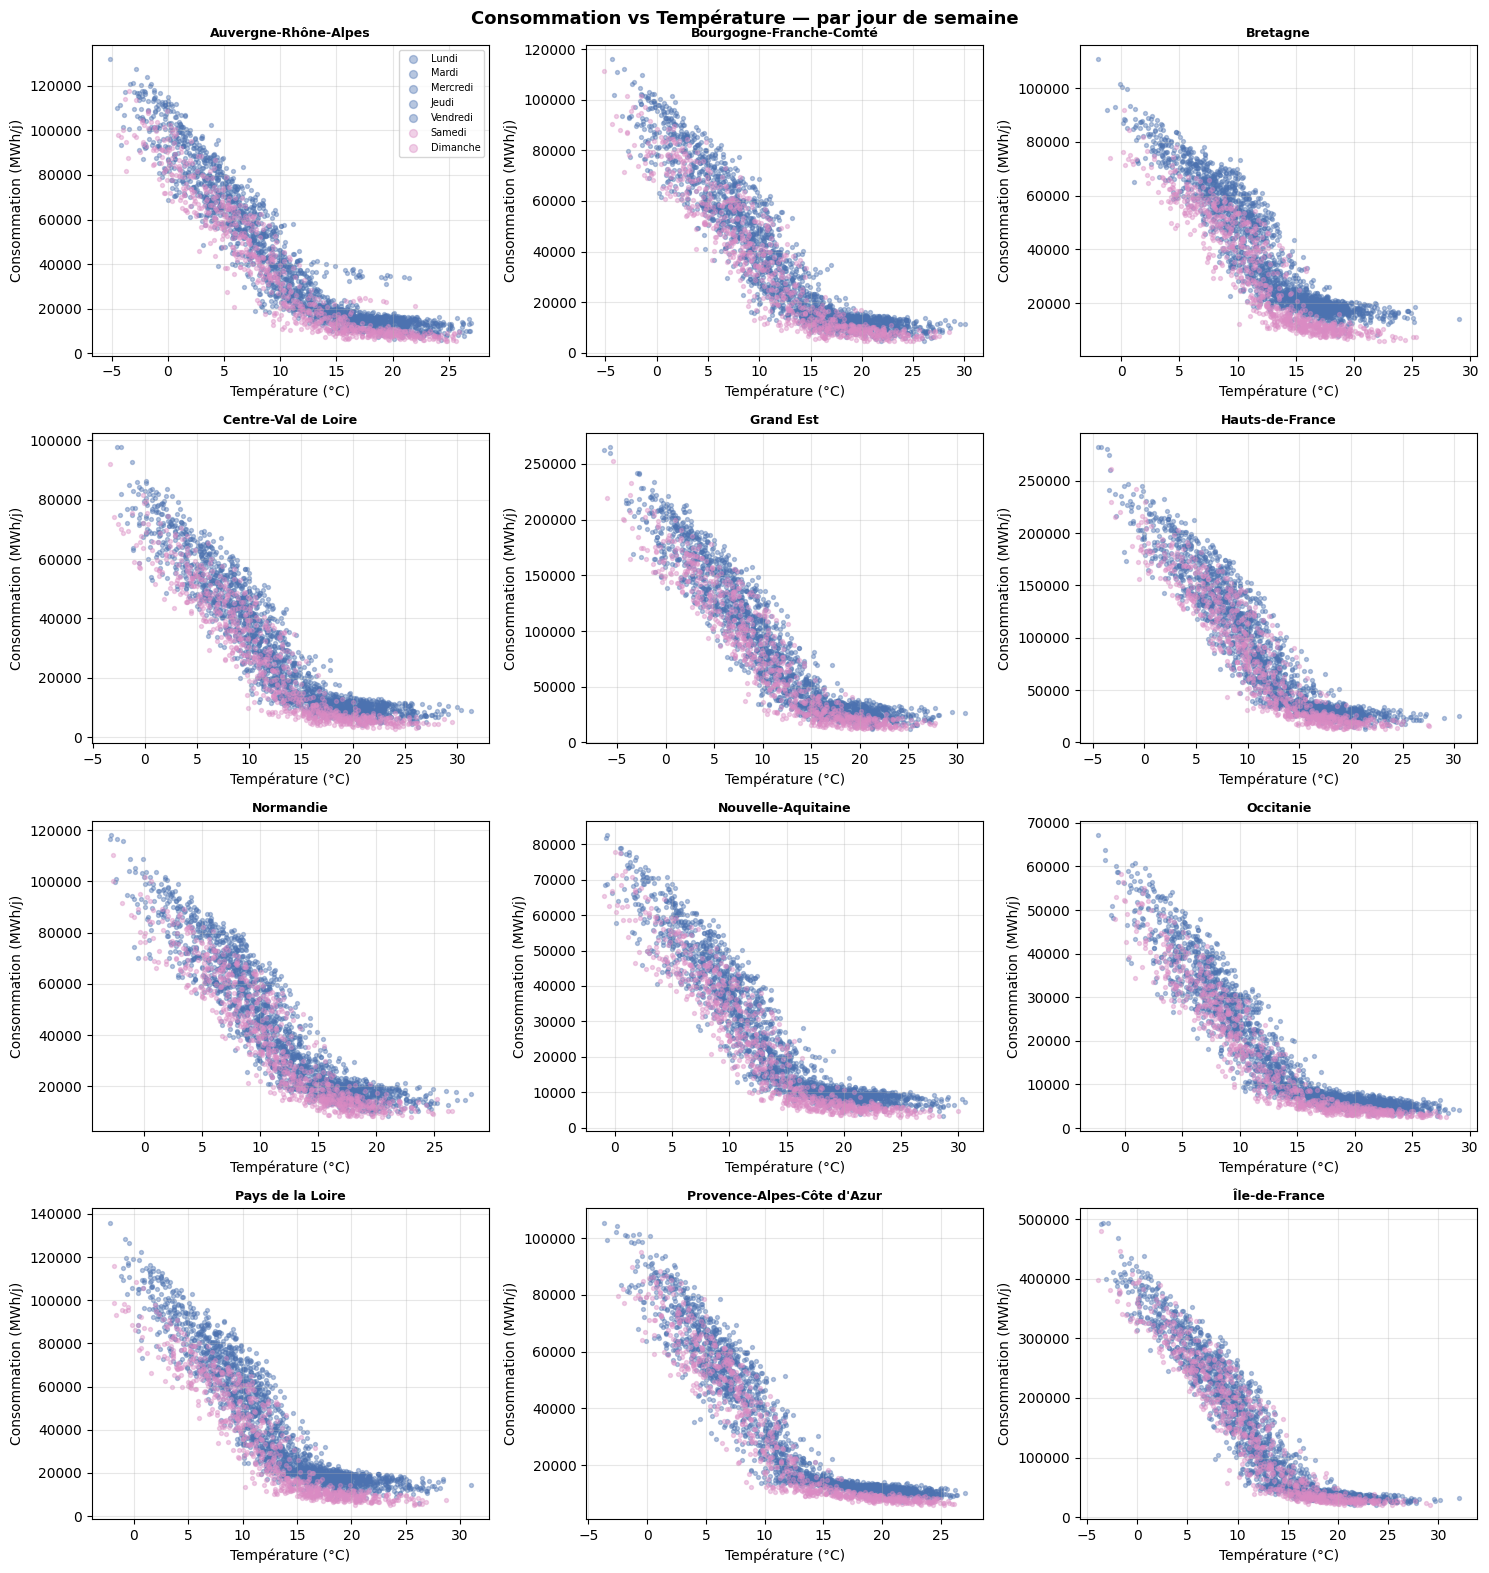

In [12]:
jours = {0: "Lundi", 1: "Mardi", 2: "Mercredi", 3: "Jeudi",
         4: "Vendredi", 5: "Samedi", 6: "Dimanche"}
couleurs_dow = {
    "Lundi": "#4C72B0", "Mardi": "#4C72B0", "Mercredi": "#4C72B0",
    "Jeudi": "#4C72B0", "Vendredi": "#4C72B0", "Samedi": "#DA8BC3", "Dimanche": "#DA8BC3"
}

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 4))
axes = axes.flatten()

for idx, region in enumerate(regions):
    ax = axes[idx]
    common = conso[region].dropna().index.intersection(temp[region].dropna().index)
    x = temp[region].loc[common]
    y = conso[region].loc[common]

    for dow, jour in jours.items():
        mask = common.dayofweek == dow
        ax.scatter(x[mask], y[mask], alpha=0.4, s=8,
                   color=couleurs_dow[jour], label=jour)

    ax.set_title(region, fontsize=9, fontweight="bold")
    ax.set_xlabel("Température (°C)")
    ax.set_ylabel("Consommation (MWh/j)")
    ax.grid(True, alpha=0.3)
    if idx == 0:
        ax.legend(fontsize=7, markerscale=2)

for idx in range(len(regions), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("Consommation vs Température — par jour de semaine", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Pays frontaliers

In [13]:
CONSO_PATH = "base_data/conso_EU_neighbours.csv"
TEMP_PATH = "base_data/temp_EU_neighbours.csv"

conso = pd.read_csv(CONSO_PATH, index_col=0, parse_dates = True)
temp = pd.read_csv(TEMP_PATH, index_col=0, parse_dates = True)

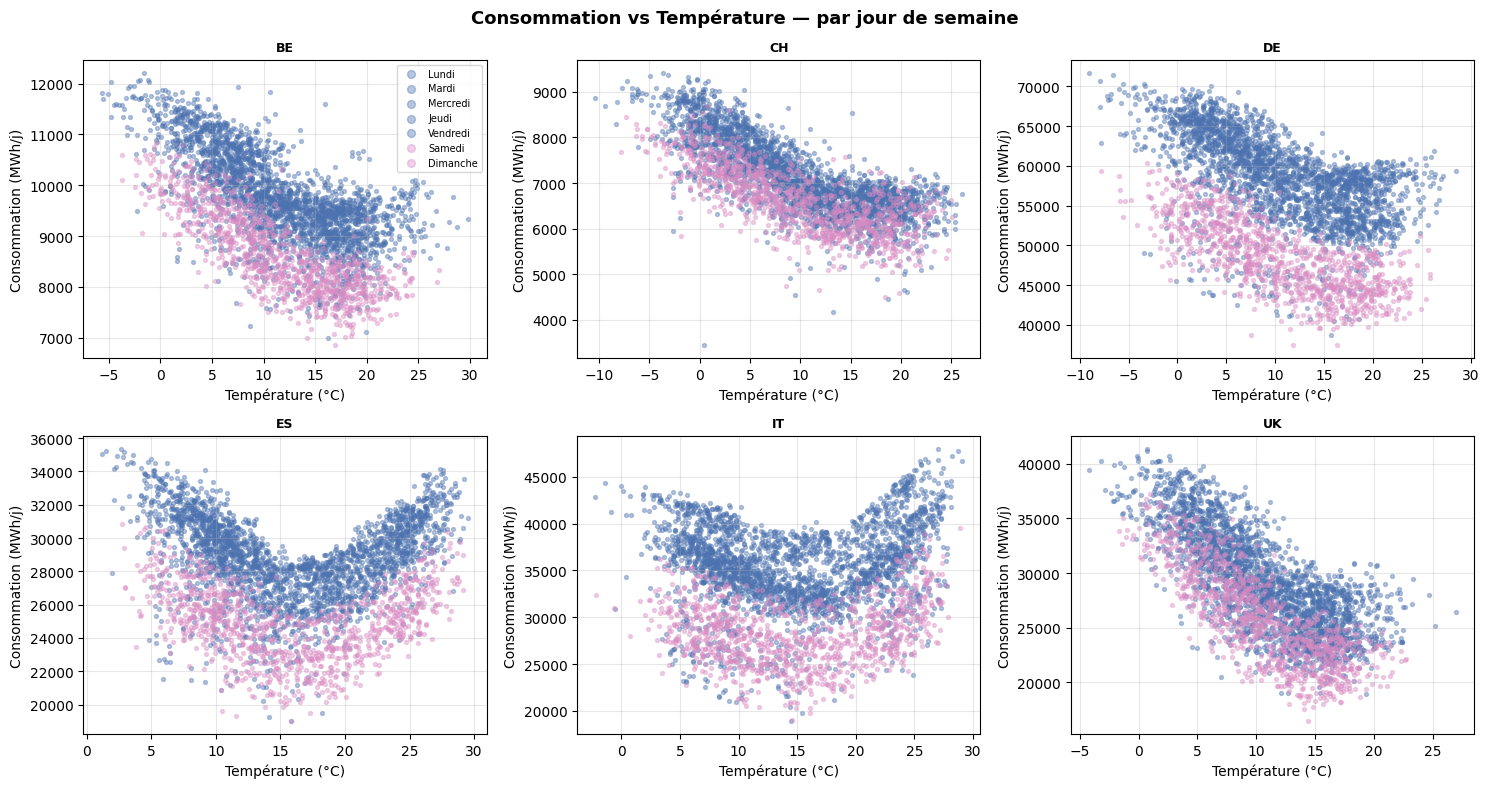

In [15]:
jours = {0: "Lundi", 1: "Mardi", 2: "Mercredi", 3: "Jeudi",
         4: "Vendredi", 5: "Samedi", 6: "Dimanche"}
couleurs_dow = {
    "Lundi": "#4C72B0", "Mardi": "#4C72B0", "Mercredi": "#4C72B0",
    "Jeudi": "#4C72B0", "Vendredi": "#4C72B0", "Samedi": "#DA8BC3", "Dimanche": "#DA8BC3"
}
regions = conso.columns.tolist()
ncols = 3
nrows = int(np.ceil(len(regions) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 4))
axes = axes.flatten()

for idx, region in enumerate(regions):
    ax = axes[idx]
    common = conso[region].dropna().index.intersection(temp[region].dropna().index)
    x = temp[region].loc[common]
    y = conso[region].loc[common]

    for dow, jour in jours.items():
        mask = common.dayofweek == dow
        ax.scatter(x[mask], y[mask], alpha=0.4, s=8,
                   color=couleurs_dow[jour], label=jour)

    ax.set_title(region, fontsize=9, fontweight="bold")
    ax.set_xlabel("Température (°C)")
    ax.set_ylabel("Consommation (MWh/j)")
    ax.grid(True, alpha=0.3)
    if idx == 0:
        ax.legend(fontsize=7, markerscale=2)

for idx in range(len(regions), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("Consommation vs Température — par jour de semaine", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()